# 4. Análisis bivariado

Este capítulo cuantifica la relación entre cada predictor y la readmisión temprana. Como en el capítulo anterior, se usa **solo el conjunto de entrenamiento**.

Dos principios guían los contrastes:

1. **La significancia no basta.** Con casi 56,000 observaciones, diferencias irrelevantes en la práctica alcanzan valores p muy pequeños. Cada contraste se acompaña de una medida de tamaño del efecto.
2. **Se corrige por comparaciones múltiples.** Se evalúan más de treinta variables; sin corrección, se esperaría alrededor de un falso positivo por cada veinte contrastes solo por azar. Se aplica la corrección de Holm-Bonferroni dentro de cada familia de contrastes.

In [1]:
from config import *

roles = roles_variables()
OBJETIVO = roles["objetivo"]
NUMERICAS = roles["numericas"] + roles["ordinales"]
CATEGORICAS = roles["categoricas"]
BINARIAS = roles["binarias"]
ETIQUETAS_EDAD = {int(k): v for k, v in roles["etiquetas_edad"].items()}

train = leer_tabla("diabetes_train")
assert train.isna().sum().sum() == 0, "El conjunto cargado tiene faltantes"
tasa_global = 100 * train[OBJETIVO].mean()
print(f"Entrenamiento: {len(train):,} pacientes | "
      f"tasa de readmisión temprana: {tasa_global:.2f} %")

Entrenamiento: 79,473 pacientes | tasa de readmisión temprana: 11.39 %


In [2]:
def correccion_holm(valores_p):
    """Corrección de Holm-Bonferroni para comparaciones múltiples.

    Controla la tasa de error familiar de forma uniformemente más potente
    que Bonferroni y sin supuestos sobre la dependencia entre contrastes.

    Parameters
    ----------
    valores_p : array_like
        Valores p sin corregir.

    Returns
    -------
    numpy.ndarray
        Valores p ajustados, monótonos y acotados en 1.
    """
    p = np.asarray(valores_p, dtype=float)
    m = len(p)
    orden = np.argsort(p)
    ajustados = np.empty(m)
    maximo = 0.0
    for i, indice in enumerate(orden):
        maximo = max(maximo, (m - i) * p[indice])
        ajustados[indice] = min(1.0, maximo)
    return ajustados


def delta_cliff(grupo_a, grupo_b):
    """Delta de Cliff a partir del estadístico U de Mann-Whitney.

    Mide la diferencia entre la probabilidad de que una observación del
    primer grupo supere a una del segundo y la probabilidad inversa. Es
    robusta a la forma de la distribución y maneja empates correctamente,
    ya que el estadístico U los pondera con medio punto.

    Returns
    -------
    float
        Valor en [-1, 1]; 0 indica ausencia de diferencia estocástica.
    """
    u = stats.mannwhitneyu(grupo_a, grupo_b).statistic
    return 2 * u / (len(grupo_a) * len(grupo_b)) - 1


def magnitud_cliff(delta):
    """Clasifica la delta de Cliff según los umbrales convencionales."""
    d = abs(delta)
    if d < 0.147:
        return "Insignificante"
    if d < 0.330:
        return "Pequeño"
    if d < 0.474:
        return "Mediano"
    return "Grande"


def v_cramer(contingencia):
    """V de Cramér con la corrección por sesgo de Bergsma.

    La corrección es necesaria con muestras grandes y tablas de muchas
    categorías, donde la V sin corregir sobrestima la asociación.

    Returns
    -------
    float
        Valor en [0, 1]; 0 indica independencia.
    """
    chi2 = stats.chi2_contingency(contingencia).statistic
    n = contingencia.values.sum()
    phi2 = chi2 / n
    r, k = contingencia.shape
    phi2_corregido = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corregido = r - (r - 1) ** 2 / (n - 1)
    k_corregido = k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2_corregido /
                   max(1e-12, min(k_corregido - 1, r_corregido - 1)))

## 4.1. Variables numéricas frente al desenlace

Al no cumplirse la normalidad (capítulo 3), la comparación entre readmitidos y no readmitidos se hace con la **U de Mann-Whitney**, que contrasta si una variable tiende a tomar valores mayores en un grupo que en el otro sin suponer una forma distribucional.

Se reportan dos tamaños de efecto complementarios. La **correlación biserial puntual** es la correlación de Pearson entre el predictor y el indicador binario, e informa sobre asociación lineal. La **delta de Cliff** mide la probabilidad de que una observación de un grupo supere a una del otro, es robusta a la forma de la distribución y se interpreta con los umbrales de 0.147 (pequeño), 0.330 (mediano) y 0.474 (grande).

In [3]:
filas = []
for columna in NUMERICAS + BINARIAS:
    grupo_1 = train.loc[train[OBJETIVO] == 1, columna]
    grupo_0 = train.loc[train[OBJETIVO] == 0, columna]
    delta = delta_cliff(grupo_1, grupo_0)
    filas.append({
        "variable": columna,
        "mediana (no readm.)": grupo_0.median(),
        "mediana (readm.)": grupo_1.median(),
        "media (no readm.)": grupo_0.mean(),
        "media (readm.)": grupo_1.mean(),
        "p (Mann-Whitney)": stats.mannwhitneyu(grupo_1, grupo_0).pvalue,
        "r biserial": stats.pointbiserialr(train[OBJETIVO], train[columna]).statistic,
        "delta de Cliff": delta,
        "magnitud del efecto": magnitud_cliff(delta),
    })

asociacion_num = pd.DataFrame(filas).set_index("variable")
asociacion_num["p (Holm)"] = correccion_holm(asociacion_num["p (Mann-Whitney)"])
asociacion_num["significativa (Holm)"] = np.where(
    asociacion_num["p (Holm)"] < 0.05, "Sí", "No")
asociacion_num = asociacion_num.reindex(
    asociacion_num["delta de Cliff"].abs().sort_values(ascending=False).index)

guardar_resultado(asociacion_num, "asociacion_numericas")
tabla(asociacion_num.round(4), filas=15)

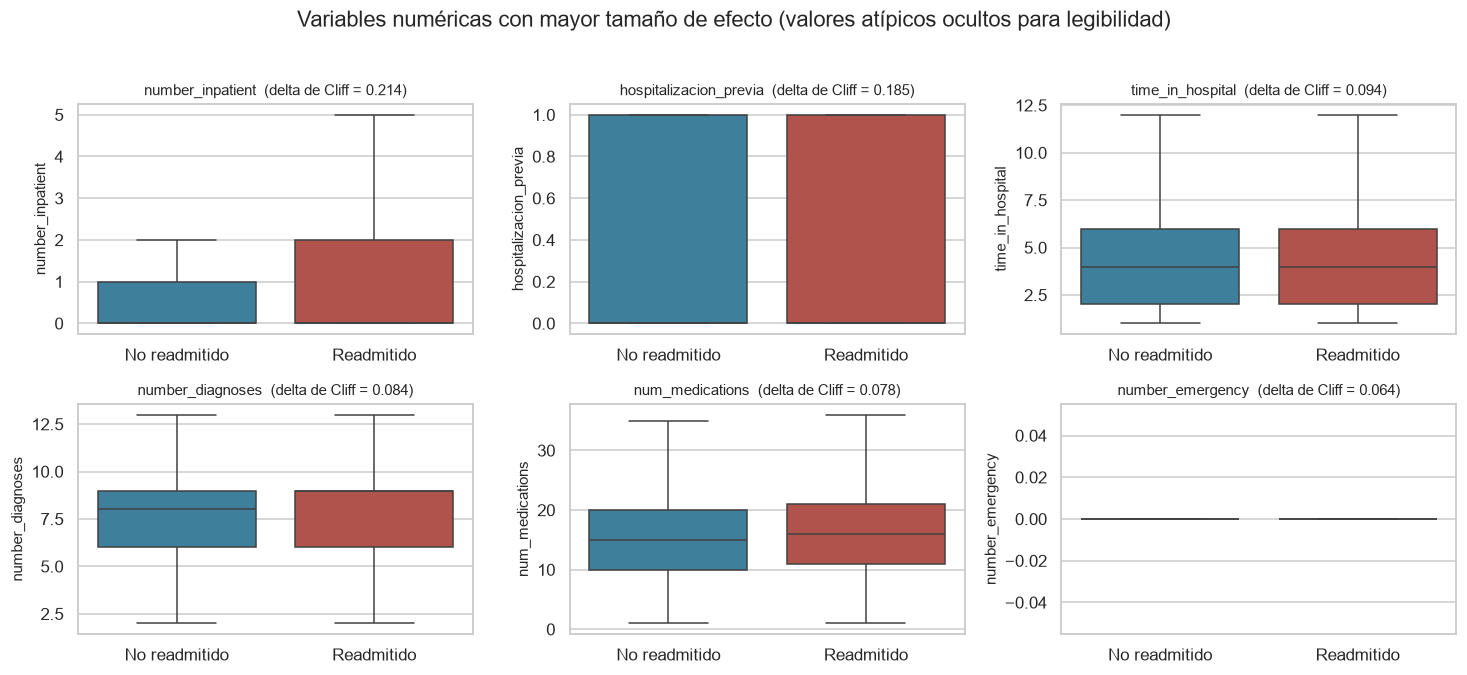

In [4]:
principales = asociacion_num.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6))
for ax, columna in zip(axes.flat, principales):
    sns.boxplot(data=train, x=OBJETIVO, y=columna, hue=OBJETIVO,
                palette=COLORES, legend=False, showfliers=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No readmitido", "Readmitido"])
    ax.set_xlabel("")
    delta = asociacion_num.loc[columna, "delta de Cliff"]
    ax.set_title(f"{columna}  (delta de Cliff = {delta:.3f})", fontsize=10)
fig.suptitle("Variables numéricas con mayor tamaño de efecto "
             "(valores atípicos ocultos para legibilidad)", y=1.02)
plt.tight_layout()
plt.show()

El resultado es el hallazgo central del análisis y condiciona las expectativas de todo el proyecto: **casi todas las asociaciones son significativas tras la corrección de Holm y ninguna tiene relevancia práctica**. La única excepción a la significancia es `num_procedures`, que no alcanza el umbral ni antes ni después de corregir.

La variable con mayor tamaño de efecto es `time_in_hospital` (delta de Cliff ≈ 0.125), seguida de `age_ord` (≈ 0.097), `number_inpatient` (≈ 0.093) y `hospitalizacion_previa` (≈ 0.090). Todas quedan por debajo del umbral de 0.147 que marca el inicio de un efecto pequeño. Conviene notar que el orden cambia según la medida: por correlación biserial el predictor más fuerte es `number_inpatient` (r ≈ 0.097), lo que ilustra que ambas métricas capturan aspectos distintos: la delta de Cliff es sensible al desplazamiento de toda la distribución, mientras que la correlación de Pearson se ve más influida por los valores extremos de las variables de conteo.

Las medianas difieren en un solo punto en las variables de proceso (`time_in_hospital` 3 frente a 4 días, `num_medications` 14 frente a 15) y son idénticas en las tres variables de utilización previa, donde la diferencia aparece únicamente en las medias. Eso indica que en las variables con exceso de ceros la señal está en las colas, no en un desplazamiento del centro de la distribución: los readmitidos no son pacientes con "algo más" de historial, sino que entre ellos hay una fracción mayor de pacientes con historial muy alto.

Esto no es un defecto del análisis, sino una propiedad del problema. La readmisión hospitalaria es multicausal y depende en buena medida de factores que los datos administrativos no registran: adherencia al tratamiento, red de apoyo familiar, acceso efectivo al seguimiento ambulatorio, condiciones socioeconómicas y de vivienda.

La consecuencia práctica es que conviene **anticipar un desempeño moderado** y dejarlo consignado antes de presentar resultados. Si algún modelo logra capacidad discriminante, provendrá de combinaciones e interacciones entre variables más que de predictores individuales, lo que a su vez sugiere que los modelos capaces de capturar interacciones (ensambles de árboles) deberían aventajar a los lineales.

## 4.2. Variables categóricas frente al desenlace

Se contrasta la independencia con la prueba **chi-cuadrado** y se mide la intensidad con la **V de Cramér** corregida por sesgo, comparable entre variables con distinto número de categorías.

### 4.2.1. Verificación de supuestos

La aproximación chi-cuadrado exige frecuencias esperadas suficientes; la regla habitual pide que ninguna celda baje de 1 y que no más del 20 % quede por debajo de 5. Se verifica explícitamente en cada tabla, porque en este dataset el supuesto **no se cumplía antes de agrupar las categorías poco frecuentes** en el capítulo 2: el destino al alta tenía el 26.2 % de las celdas con frecuencia esperada menor que 5, y la fuente de admisión el 35.3 %.

In [5]:
filas = []
for columna in CATEGORICAS:
    contingencia = pd.crosstab(train[columna], train[OBJETIVO])
    chi2, p, gl, esperadas = stats.chi2_contingency(contingencia)
    filas.append({
        "variable": columna,
        "categorías": contingencia.shape[0],
        "mín. frecuencia esperada": esperadas.min(),
        "% celdas con esperada < 5": 100 * (esperadas < 5).mean(),
        "chi²": chi2,
        "gl": gl,
        "p": p,
        "V de Cramér": v_cramer(contingencia),
    })

asociacion_cat = pd.DataFrame(filas).set_index("variable")
asociacion_cat["p (Holm)"] = correccion_holm(asociacion_cat["p"])
asociacion_cat["supuesto chi² cumplido"] = np.where(
    (asociacion_cat["mín. frecuencia esperada"] >= 1)
    & (asociacion_cat["% celdas con esperada < 5"] <= 20), "Sí", "No")
asociacion_cat["significativa (Holm)"] = np.where(
    asociacion_cat["p (Holm)"] < 0.05, "Sí", "No")
asociacion_cat = asociacion_cat.sort_values("V de Cramér", ascending=False)

guardar_resultado(asociacion_cat, "asociacion_categoricas")
tabla(asociacion_cat.round(4), filas=30)

Tras el agrupamiento del capítulo 2 todas las variables cumplen el supuesto, de modo que los valores p son interpretables. Merece registrarse un efecto secundario del agrupamiento: en `admission_source_id` la V de Cramér cae de forma apreciable al agrupar las categorías raras, porque parte de la asociación aparente provenía de celdas con muy pocos casos y estimaciones inestables. El valor agrupado es el estimador honesto, aunque resulte menos favorable.

La corrección por comparaciones múltiples también cambia conclusiones. Diez de las 27 variables categóricas mantienen significancia tras Holm, encabezadas por el destino al alta, los tres grupos diagnósticos, la especialidad y el bloque de tratamiento (`diabetesMed`, `insulin`, `change`, `repaglinide`, `glipizide`). Las otras 17 no la mantienen. Cuatro de ellas resultan especialmente ilustrativas: `race`, `metformin`, los dos identificadores de admisión y, de forma notable, las dos pruebas de laboratorio **dejan de ser significativas** al corregir. Sus valores p sin ajustar quedaban entre 0.004 y 0.10, justo el rango donde la corrección marca la diferencia; sin ella se habrían reportado como hallazgos.

### 4.2.2. Tasa de readmisión por categoría

La V de Cramér mide intensidad global, pero no dice qué categorías concentran el riesgo. Se examina la tasa de readmisión por nivel, restringida a categorías con al menos 200 pacientes en entrenamiento para que las estimaciones sean estables, y acompañada de un intervalo de confianza binomial.

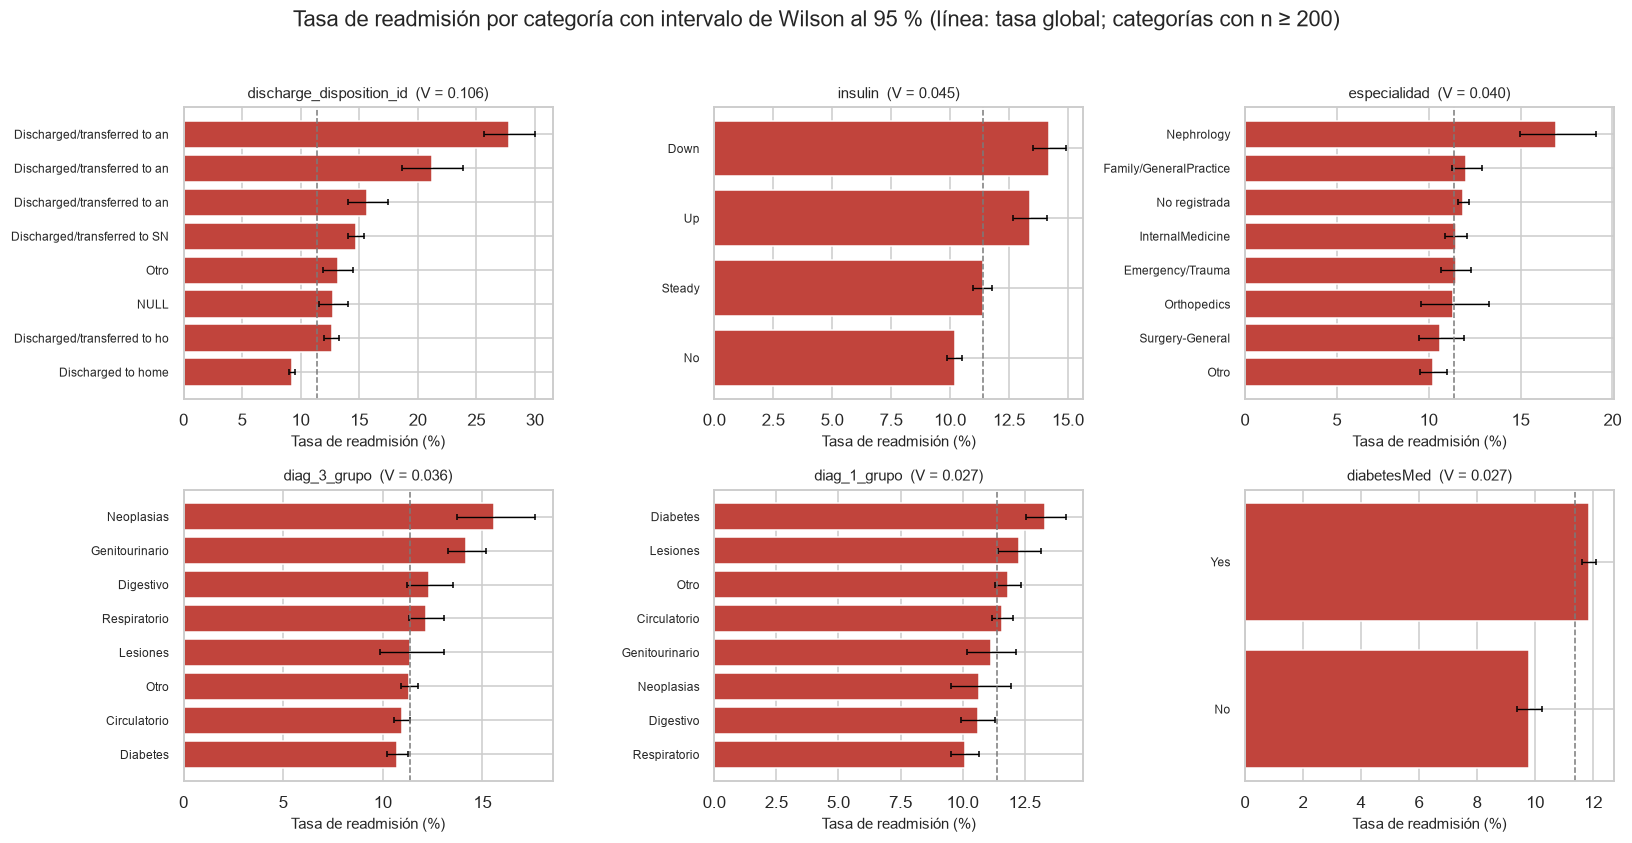

In [6]:
def intervalo_wilson(exitos, total, confianza=0.95):
    """Intervalo de confianza de Wilson para una proporción.

    Preferible al intervalo normal cuando la proporción es pequeña o el
    tamaño del grupo es reducido, situaciones en las que el intervalo
    clásico puede incluir valores negativos.

    Returns
    -------
    tuple of float
        Límites inferior y superior de la proporción.
    """
    if total == 0:
        return (np.nan, np.nan)
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    p = exitos / total
    centro = (p + z ** 2 / (2 * total)) / (1 + z ** 2 / total)
    margen = (z / (1 + z ** 2 / total)) * np.sqrt(
        p * (1 - p) / total + z ** 2 / (4 * total ** 2))
    return centro - margen, centro + margen


def tasa_por_categoria(datos, columna, minimo=200):
    """Tasa de readmisión por categoría con intervalo de Wilson al 95 %."""
    agrupado = datos.groupby(columna)[OBJETIVO].agg(["size", "sum", "mean"])
    agrupado = agrupado[agrupado["size"] >= minimo]
    limites = [intervalo_wilson(fila["sum"], fila["size"])
               for _, fila in agrupado.iterrows()]
    agrupado["inferior"] = [100 * l[0] for l in limites]
    agrupado["superior"] = [100 * l[1] for l in limites]
    agrupado["tasa (%)"] = 100 * agrupado["mean"]
    return agrupado.sort_values("tasa (%)", ascending=False)


DESTACADAS = asociacion_cat.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, columna in zip(axes.flat, DESTACADAS):
    resumen = tasa_por_categoria(train, columna).head(8)
    posiciones = np.arange(len(resumen))[::-1]
    ax.barh(posiciones, resumen["tasa (%)"], color=PALETA[1])
    ax.errorbar(resumen["tasa (%)"], posiciones,
                xerr=[resumen["tasa (%)"] - resumen["inferior"],
                      resumen["superior"] - resumen["tasa (%)"]],
                fmt="none", ecolor="black", elinewidth=0.9, capsize=2)
    ax.set_yticks(posiciones)
    ax.set_yticklabels([str(i)[:28] for i in resumen.index], fontsize=8)
    ax.axvline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_xlabel("Tasa de readmisión (%)")
    ax.set_title(f"{columna}  (V = {asociacion_cat.loc[columna, 'V de Cramér']:.3f})",
                 fontsize=10)
fig.suptitle("Tasa de readmisión por categoría con intervalo de Wilson al 95 % "
             "(línea: tasa global; categorías con n ≥ 200)", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
tabla(tasa_por_categoria(train, "discharge_disposition_id")[
    ["size", "tasa (%)", "inferior", "superior"]].round(2), filas=15)

El destino al alta es, con diferencia, la variable categórica más asociada al desenlace. Los pacientes trasladados a otras instituciones de cuidado (rehabilitación, centros de larga estancia, atención domiciliaria) presentan tasas que superan claramente la media, con intervalos de confianza que no la incluyen, mientras que el alta a domicilio queda por debajo. El patrón es clínicamente coherente: el destino al alta resume la fragilidad del paciente y la intensidad del cuidado que requiere.

Es importante señalar que esta variable se determina **en el momento del alta**, por lo que su uso como predictor es legítimo y no constituye fuga de información.

La especialidad médica y el grupo etario siguen en orden de asociación, con intensidades bastante menores. El resto de variables, incluida la mayoría del panel farmacológico, muestra asociaciones cercanas a cero.

## 4.3. Bloque clínico: control glucémico y tratamiento

Las dos pruebas de laboratorio y el manejo farmacológico merecen un examen específico: son el núcleo clínico del dataset y motivaron su publicación original, que se centró justamente en el efecto de medir la hemoglobina glicosilada sobre la readmisión.

In [8]:
CLINICAS = ["A1Cresult", "max_glu_serum", "insulin", "change", "diabetesMed"]

filas = []
for columna in CLINICAS:
    for categoria, grupo in train.groupby(columna):
        inferior, superior = intervalo_wilson(grupo[OBJETIVO].sum(), len(grupo))
        filas.append({
            "variable": columna,
            "categoría": categoria,
            "pacientes": len(grupo),
            "tasa (%)": 100 * grupo[OBJETIVO].mean(),
            "IC 95 % inferior": 100 * inferior,
            "IC 95 % superior": 100 * superior,
        })

resumen_clinico = pd.DataFrame(filas).round(2)
tabla(resumen_clinico, filas=25)

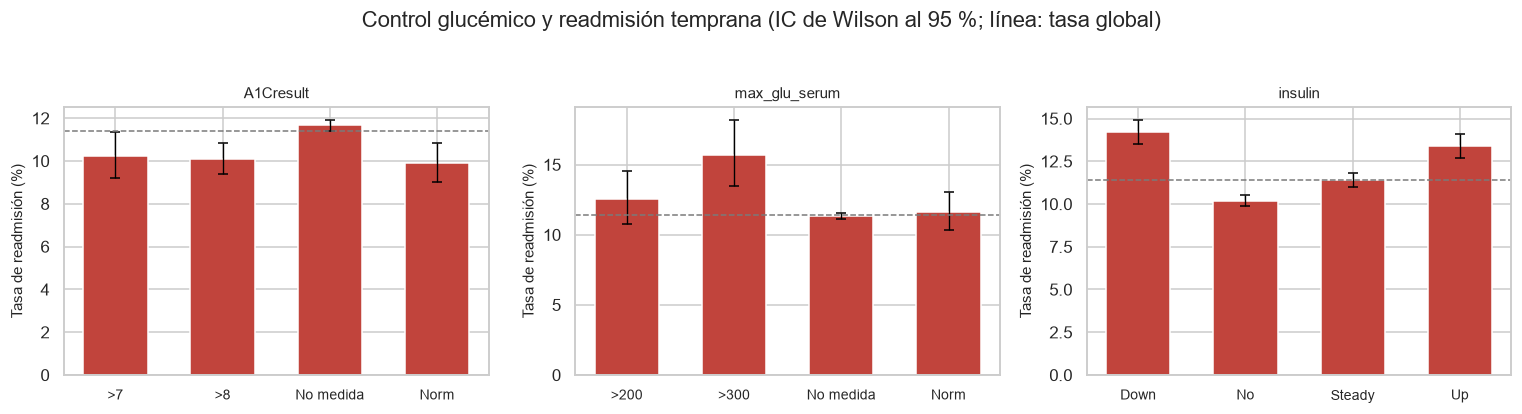

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, columna in zip(axes, ["A1Cresult", "max_glu_serum", "insulin"]):
    sub = resumen_clinico[resumen_clinico["variable"] == columna]
    posiciones = np.arange(len(sub))
    ax.bar(posiciones, sub["tasa (%)"], color=PALETA[1], width=0.6)
    ax.errorbar(posiciones, sub["tasa (%)"],
                yerr=[sub["tasa (%)"] - sub["IC 95 % inferior"],
                      sub["IC 95 % superior"] - sub["tasa (%)"]],
                fmt="none", ecolor="black", elinewidth=0.9, capsize=3)
    ax.axhline(tasa_global, ls="--", color=GRIS, lw=1)
    ax.set_xticks(posiciones)
    ax.set_xticklabels(sub["categoría"], fontsize=9)
    ax.set_ylabel("Tasa de readmisión (%)")
    ax.set_title(columna, fontsize=10)
fig.suptitle("Control glucémico y readmisión temprana "
             "(IC de Wilson al 95 %; línea: tasa global)", y=1.04)
plt.tight_layout()
plt.show()

El resultado es llamativo y merece discusión explícita en el artículo: **el control glucémico medido no discrimina el riesgo de readmisión temprana**. Las tasas son prácticamente idénticas entre pacientes con hemoglobina glicosilada normal, elevada o no medida, y los intervalos de confianza se solapan ampliamente. La prueba chi-cuadrado de `A1Cresult` no sobrevive la corrección por comparaciones múltiples, y la de `max_glu_serum` no es significativa ni siquiera sin corregir.

El uso de insulina y el cambio de medicación sí mantienen significancia, pero con V de Cramér en torno a 0.026 y diferencias de uno a dos puntos porcentuales en la tasa de readmisión: significativas por el tamaño de muestra, irrelevantes en la práctica clínica.

Hay dos lecturas posibles, no excluyentes:

1. La readmisión a 30 días responde más a factores organizativos y sociales que al control metabólico puntual durante el ingreso.
2. El efecto existe pero queda enmascarado por **confusión por indicación**: la decisión de medir la hemoglobina glicosilada no es aleatoria, sino que depende del estado del paciente. Los pacientes a quienes se mide son sistemáticamente distintos de aquellos a quienes no, y esa diferencia puede compensar el efecto del control glucémico.

La segunda lectura es una limitación estructural de los datos observacionales y debe declararse como tal: con este diseño no es posible separar el efecto de medir del efecto de la condición que motivó la medición.

### 4.4. Síntesis del capítulo

| Dimensión | Hallazgo |
|---|---|
| Predictor numérico más asociado | `time_in_hospital` (delta de Cliff ≈ 0.125, efecto insignificante); por correlación biserial, `number_inpatient` (r ≈ 0.097) |
| Predictor categórico más asociado | `discharge_disposition_id` (V de Cramér ≈ 0.128) |
| Significancia frente a relevancia | Todos los contrastes numéricos salvo `num_procedures` sobreviven Holm; ninguno alcanza siquiera un efecto pequeño |
| Efecto de la corrección múltiple | `race`, `admission_source_id`, `metformin` y las dos pruebas de laboratorio pierden la significancia al corregir |
| Forma de la asociación | Medianas iguales y medias distintas en las variables con exceso de ceros: la señal está en las colas, no en un desplazamiento distribucional |
| Supuestos | Verificados en todas las tablas de contingencia tras el agrupamiento del capítulo 2, que era imprescindible |
| Control glucémico | Sin capacidad discriminante; posible confusión por indicación, declarada como limitación |
| Expectativa de desempeño | Moderada. La capacidad predictiva, si aparece, vendrá de interacciones, lo que favorece a los ensambles de árboles sobre los modelos lineales |